In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [145]:
df = pd.read_csv("/Users/pret/unil/Bacteriocin_Projects/fconsta_pipeline/outputs_from_GPS/PA_table_with_annotation_counts.csv")
## filtering to unique contigs to prevent duplicates
df = df.drop_duplicates(subset= ["GCA_ID"])
print(len(df))
print(df.columns)
print(df["Bacteriocin precursor"].unique())

/var/folders/qy/yjb83c7551s1z1rlbz7twrrw0000gn/T/ipykernel_34025/3537386168.py:1: DtypeWarning: Columns (51) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/Users/pret/unil/Bacteriocin_Projects/fconsta_pipeline/outputs_from_GPS/PA_table_with_annotation_counts.csv")


13532
Index(['Unnamed: 0', 'ENA_lane_id', 'blpA_non_functional', 'blpA_functional',
       'blph', 'blpr', 'pncp', 'blpl', 'blpt', 'blpx', 'blpz', 'pncm', 'pncg',
       'blpb', 'blps', 'blpc', 'blpk', 'pncw', 'blpo', 'blpu', 'blpy', 'blpm',
       'blpp', 'blpn', 'blpi', 'blpj', 'blpf', 'blpv', 'blpq', 'pnct', 'tdpa',
       'Isolate', 'GCA_ID', 'Public_name', 'Sample_name', 'ERS', 'ERR',
       'Published', 'Selection_random', 'Continent', 'Country', 'Region',
       'Latitude', 'Longitude', 'Year', 'Age_years', 'Less_than_5_years_old',
       'Clinical_manifestation', 'Source', 'Manifestation', 'Pipeline_version',
       'In_silico_ST', 'GPSC', 'In_silico_serotype', 'pbp1a', 'pbp2b', 'pbp2x',
       'WGS_PEN', 'WGS_PEN_SIR_Meningitis', 'ermB', 'mefA', 'folA_I100L',
       'folP__autocolour', 'cat', 'Vaccine_period', 'PCV7', 'PCV10_GSK',
       'PCV13', 'PCV15', 'PCV20', 'IVT25', 'Other', 'Transporter', 'Immunity',
       'Unknown', 'Modification', 'Bacteriocin precursor', 'Regulatio

Text(0.5, 1.0, 'Genotype distribution of GPS data (worldwide)')

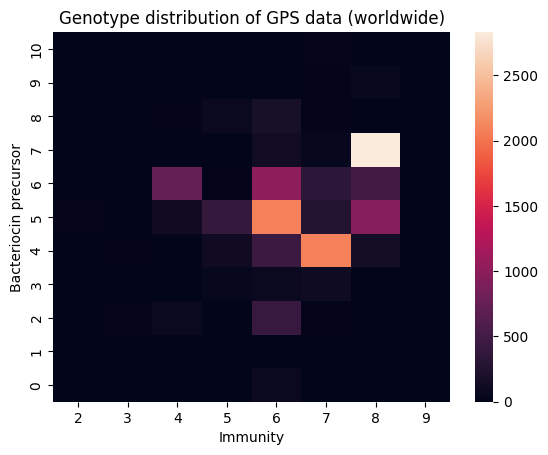

In [10]:
## Making a heatmap of the different values
counts_tox = df["Bacteriocin precursor"].value_counts()
counts = df.groupby(by =["Bacteriocin precursor", "Immunity"]).size().unstack(fill_value=0)
ax = sns.heatmap(counts)
ax.invert_yaxis()
ax.set_title("Genotype distribution of GPS data (worldwide)")

[2, 3, 4, 5, 6, 7, 8, 9, '']


/var/folders/qy/yjb83c7551s1z1rlbz7twrrw0000gn/T/ipykernel_34025/2021617144.py:45: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  new_df = new_df.fillna(0.0)
/var/folders/qy/yjb83c7551s1z1rlbz7twrrw0000gn/T/ipykernel_34025/2021617144.py:45: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  new_df = new_df.fillna(0.0)
/var/folders/qy/yjb83c7551s1z1rlbz7twrrw0000gn/T/ipykernel_34025/2021617144.py:45: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) 

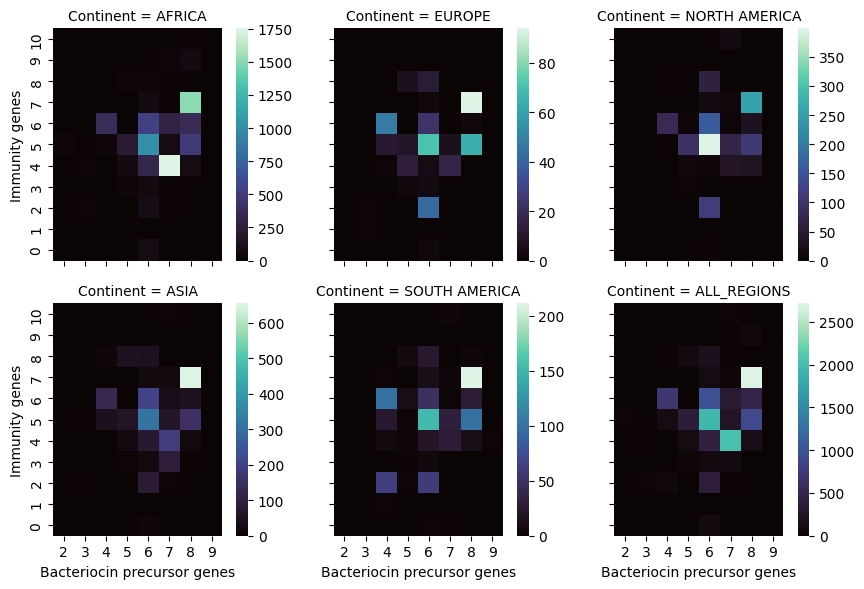

In [260]:
## Breaking down above plot by continent
axes = 0 
facet_df = pd.DataFrame()
grouped_counts = pd.DataFrame()

def draw_heatmap(data, **kwargs):
    data = data.drop("Continent", axis=1)
    data = data.astype(float)
    sns.heatmap(data, square=True,  **kwargs)

## The data needs to be broken into a flat index
## The pandas reset_index() command wasnt working, so I did this instead
for cont in df.Continent.unique():
    data = df[df["Continent"] == cont]
    counts = data.groupby(by =["Bacteriocin precursor", "Immunity"]).size().to_frame().reset_index().pivot(index="Bacteriocin precursor", columns="Immunity")
    counts = counts.reset_index()
    if len(counts) != 0:
        counts["Continent"] = cont
        grouped_counts = pd.concat([grouped_counts, counts])

old_columns = [x[1] for x in grouped_counts.columns[1:]]
print(old_columns)
grouped_counts = grouped_counts.fillna(0.0)
grouped_counts = grouped_counts.to_numpy()

grouped_counts = pd.DataFrame(grouped_counts)
grouped_counts = grouped_counts.set_index(0)

new_cols = {v:k for k,v in zip(old_columns, grouped_counts.columns)}
new_cols[grouped_counts.columns[-1]] = "Continent"

grouped_counts = grouped_counts.rename(columns=new_cols)

## the plot will break if we dont include the same index for each subset
## to handle this, we iterate over each continent and add missing indices
for cont in grouped_counts["Continent"].unique():
    indices = set(grouped_counts.index)
    data = grouped_counts[grouped_counts["Continent"] == cont]
    ## getting the indices not in the dataset
    missing_indices = list(indices - set(data.index))
    ## adding missing indices to the main dataframe
    if len(missing_indices) > 0:
        new_df = pd.DataFrame(index = missing_indices, columns = grouped_counts.columns)
        new_df["Continent"] = cont
        new_df = new_df.fillna(0.0)
        grouped_counts = pd.concat([grouped_counts, new_df])
grouped_counts = grouped_counts.sort_values(by = "Continent")
grouped_counts = grouped_counts.sort_index()

## dropping the oceania data since it has <10 samples, replacing it with an "OVERALL" continent
grouped_counts = grouped_counts[grouped_counts["Continent"] != "OCEANIA"]
overall = grouped_counts.drop(columns="Continent").groupby(level=0).sum()
overall["Continent"] = "ALL_REGIONS"
grouped_counts = pd.concat([grouped_counts, overall])



g = sns.FacetGrid(grouped_counts, col = "Continent", col_wrap = 3)


g.map_dataframe(draw_heatmap, cbar = True, cmap = "mako")
g.figure.axes[0].invert_yaxis()
g.set_xlabels("Bacteriocin precursor genes")
g.set_ylabels("Immunity genes")
g.tight_layout()